# Model Evaluation and Selection

## Project Goal

The goal of this project is to find the best model for our data.

I will train different polynomial models and compare their errors. I will use cross-validation error to select the best model and test error to check its performance on new data.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

## 1. Create the Dataset

I created a small dataset with 50 examples.

The input (`x`) represents a value between 0 and 10. The output (`y`) follows a square-root pattern with some random noise.

I will use this dataset to train and compare different models.

In [ ]:
rng = np.random.default_rng(1)
x = rng.uniform(0, 10, size=(50, 1))                      
y = 3 * np.sqrt(x) + rng.normal(0, 0.3, size=(50, 1))

## 2. Split the Dataset

I divided the dataset into three parts:

- **Training set:** Used to train the model.
- **Cross-validation set:** Used to compare models and choose the best one.
- **Test set:** Used to check the final model on data it has not seen before.

I used 60% of the data for training, 20% for cross-validation, and 20% for testing.

In [3]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size= 0.4, random_state=1)

In [4]:
x_cv, x_test, y_cv, y_test = train_test_split(x_temp, y_temp, test_size= 0.5, random_state=1)

In [5]:
print(x_train.shape, x_cv.shape, x_test.shape)
print(y_train.shape, y_cv.shape, y_test.shape)

(30, 1) (10, 1) (10, 1)
(30, 1) (10, 1) (10, 1)


## 3. Train Different Models

I trained 10 polynomial models, from degree 1 to degree 10.

A degree 1 model is a straight line. Higher-degree models can learn more complex patterns in the data.

I trained each model using the training set. I then calculated its training error and cross-validation error to compare its performance.

In [42]:
train_errors = []
cv_errors = []

save_poly = 0
save_scaler = 0 
save_model = 0

for i in range(1, 11):
    
    poly = PolynomialFeatures(degree=i, include_bias=False)
    x_train_poly = poly.fit_transform(x_train)
    x_cv_poly = poly.transform(x_cv)

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_poly)
    x_cv_scaled= scaler.transform(x_cv_poly)
    
    model = LinearRegression()
    model.fit(x_train_scaled, y_train)
    
    y_train_pred = model.predict(x_train_scaled)
    y_cv_pred = model.predict(x_cv_scaled)
    
    train_error = mean_squared_error(y_train, y_train_pred) / 2
    cv_error = mean_squared_error(y_cv, y_cv_pred) / 2
    
    train_errors.append(train_error)
    cv_errors.append(cv_error)

    # if i == best_degree:
    #     save_poly = x_cv_poly[i]
    #     save_scaler = x_cv_scaled[i]
    #     save_model = y_train_pred[i]


best_index = np.argmin(cv_errors)
best_degree = best_index + 1

    
    
    

## 4. Compare Model Errors

After training each model, I calculated its training error and cross-validation error.

- **Training error** shows how well the model fits the training data.
- **Cross-validation error** helps me understand how well the model works on data it did not train on.

I compared the errors for all 10 models to find the best model.

A low training error does not always mean that a model is the best choice. I also need to check its cross-validation error.

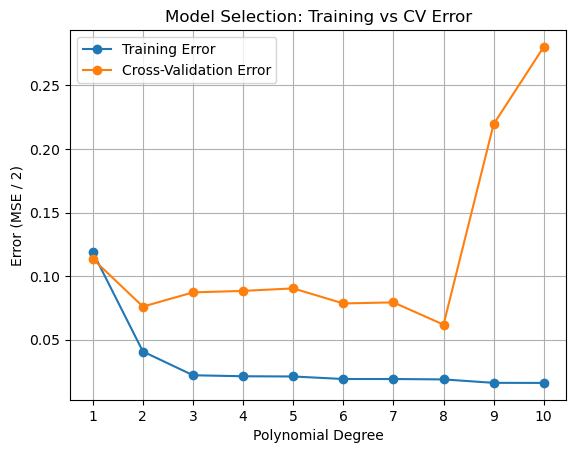

In [ ]:
degrees = range(1, 11)

plt.plot(degrees, train_errors, marker='o', label='Training Error')
plt.plot(degrees, cv_errors, marker='o', label='Cross-Validation Error')

plt.xlabel('Polynomial Degree')
plt.ylabel('Error (MSE / 2)')
plt.title('Model Selection: Training vs CV Error')

plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()


## 5. Train the Best Model

I created a polynomial model using the best degree selected through cross-validation.

I trained the model using the training data. I also scaled the data using `StandardScaler` to keep the same scaling for the test data.

Finally, I transformed the test data using the same polynomial features and scaler.

In [44]:
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
x_train_poly = poly.fit_transform(x_train)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_poly)

model = LinearRegression()
model.fit(x_train_scaled, y_train)

x_test_poly = poly.transform(x_test)
x_test_scaled = scaler.transform(x_test_poly)

## 6. Evaluate the Model

I used the trained model to make predictions on the test data.

I then calculated the test error to check how well the model performed on data it had not seen during training.

The best degree was 8, and the test error was approximately 0.0243.

In [45]:
y_test_pred = model.predict(x_test_scaled)

test_error = mean_squared_error(y_test, y_test_pred) / 2

print("Best degree:", best_degree)
print("Test error:", test_error)

Best degree: 8
Test error: 0.02430258137456027
